# Análisis exploratorio de datos | Datos históricos del precio del Bitcoin



## Introducción y contexto
### Objetivo del análisis

#### Objetivo general
- Comprender la estructura y características generales de la serie histórica de precios del Bitcoin.

#### Objetivos específicos
- Deescribir las principales caracteristicas del conjunto de datos como su estructura, dimensiones, datos faltantes buscando identificar mediante el análisis de funciones de autocorrelación y agrupaciones temporales las frecuencias más dominantes.
- Analizar la tendencia a largo plazo de la serie, aplicando métodos de suavizamineto, pruebas de estacionariedad y transformaciones de datos para corregir cambios en la media y varianza en el timepo
- Examinar anomalias o eventos extremos contextualizacion los posibles eventos externos relevantes
- Sintetizar los resultados más relevantes y las problemáticas detectadas construyendo recomendaciones para la siguiente fase del proyecto.

### Descripción de los datos
El Bitcoin es una criptomoneda descentralizada nacida en el año 2008 por una entidad conocida como Satoshi Nakamoto. Su principal diferenciador frente a las monedas tradicionales y reguladas, es el uso de blockchain para poder realizar transferencias bancarias sin necesidad de tener un intermediario financiero. Su popularidad de debe a su alta volatilidad, alzas astronómicas en su valor durante la pandemia, una oferta limitada de 21 millones de unidades, e inmediatez en las transacciones globales.
El conjunto de datos escogido para ser utilizados en este proyecto es titulado "Bitcoin Historical Data" y fue publicado en la Kaggle, una de las comunidades para cientificos de datos más populares en todo el mundo. El dataset presenta una serie temporal que describe desde el año 2012 el precio registrado del Bitcoin frente al dólar estadounidense registrado por minuto, lo cual permite explorar con mucha granularidad el comportamiento de la serie. Adicionalmente, resulta importante mencionar qué variables ayudan a describir los datos:

- Open: Precio de apertura
- High: Precio máximo en una ventana de tiempo 
- Low: Precio minimo en una ventana de tiempo 
- Close: Precio de cierre
- Volume: Volumen de BTC transaccionado en la ventana de tiempo 

Resulta importante resaltar que los precios están expresados en dólares estadounidenses (USD) y el volumen representa la cantidad de Bitcoin negociada (BTC). 

## Análisis preliminar

### Inspección general
#### Dimensiones del conjunto de datos
Primero, se revisa la dimensión general del dataset. Este paso resulta relevante para poder establecer la complejidad computacional del ejercico

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from tabulate import tabulate
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')



In [4]:
datos = pd.read_csv('/Users/pctm/Desktop/Universidad/Sem 6/btcusd_1-min_data.csv')
pd.options.display.float_format = '{:,.2f}'.format
print(datos.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7457440 entries, 0 to 7457439
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 341.4 MB
None


Como vemos, el presente dataset cuenta con 7.457.440 observaciones descritas con la ayuda de 6 variables:
- **Timestamp**: Contiene información sobre la ventana de tiempo referencia de cada observación.
- **Open**: Precio de apertura
- **High**: Precio máximo en una ventana de tiempo 
- **Low**: Precio minimo en una ventana de tiempo 
- **Close**: Precio de cierre
- **Volume**: Volumen de BTC transaccionado en la ventana de tiempo 


## Dimensiones del conjunto de datos a utilizar
Para el presente proyecto, solamente se tendrán en cuenta los datos registrados desde el año 2019 y serán agrupados en intervalos de 15 minutos. Esto se hará con el objetivo de estudiar el comportamiento más reciente de la distribución y para adaptar el costo computacional del estudio a las capacidades actuales de nuestras herramientas.

In [5]:
datos["TimestampConventional"] = pd.to_datetime(datos["Timestamp"], unit="s")
datos.set_index("TimestampConventional", inplace=True)

df = datos['2019':][["Open","High","Low","Close", "Volume"]].resample('15T').mean()
df.info()


/var/folders/x3/pv5pxgpn24d3dg_tsmkjptgc0000gn/T/ipykernel_71994/2493197735.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = datos['2019':][["Open","High","Low","Close", "Volume"]].resample('15T').mean()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251809 entries, 2019-01-01 00:00:00 to 2026-03-08 00:00:00
Freq: 15min
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Open    251733 non-null  float64
 1   High    251733 non-null  float64
 2   Low     251733 non-null  float64
 3   Close   251733 non-null  float64
 4   Volume  251733 non-null  float64
dtypes: float64(5)
memory usage: 11.5 MB


Ahora, se cuenta con un total de 251.733 observaciones. Adicionalmente, dado que la variable tiempo está almacenada en formato de timestamp Unix, se añadió una nueva columna llamada TimestampConventional con un formato de fecha y hora más legible para mejorar la claridad del análisis.

#### Primeros y ultimos valores
A continuación se procede a revisar los primeros y ultimos registros para verificar la coherencia temporal

In [6]:
print(df.head())
print(df.tail())

                          Open     High      Low    Close  Volume
TimestampConventional                                            
2019-01-01 00:00:00   3,746.45 3,747.96 3,744.77 3,746.23    7.07
2019-01-01 00:15:00   3,742.76 3,743.50 3,741.85 3,742.40    1.96
2019-01-01 00:30:00   3,740.07 3,741.80 3,733.33 3,734.86    9.68
2019-01-01 00:45:00   3,670.15 3,679.61 3,663.98 3,672.69   21.49
2019-01-01 01:00:00   3,679.57 3,683.13 3,676.71 3,680.01    5.89
                           Open      High       Low     Close  Volume
TimestampConventional                                                
2026-03-07 23:00:00   67,316.73 67,335.07 67,306.00 67,319.87    0.54
2026-03-07 23:15:00   67,353.80 67,365.60 67,347.80 67,358.00    0.47
2026-03-07 23:30:00   67,358.53 67,365.20 67,349.53 67,356.53    0.97
2026-03-07 23:45:00   67,284.80 67,290.07 67,277.00 67,281.07    0.66
2026-03-08 00:00:00   67,269.00 67,308.00 67,269.00 67,308.00    0.54


Luego de la conversión, se puede ver que el inicio de la recopilación de los datos comienza desde el primero de enero del año 2019, mientras el último registro coincide con el 7 de marzo.

#### Identificación de valores faltantes
Finalmente, en esta sección se revisarán los valores faltantes de la serie.

In [7]:
print(df.isna().sum(), "valores faltantes")
print(df.isna().sum() / len(df) * 100, "% de valores faltantes")

faltantes = df[df.isna()]
print(faltantes)


Open      76
High      76
Low       76
Close     76
Volume    76
dtype: int64 valores faltantes
Open     0.03
High     0.03
Low      0.03
Close    0.03
Volume   0.03
dtype: float64 % de valores faltantes
                       Open  High  Low  Close  Volume
TimestampConventional                                
2019-01-01 00:00:00     NaN   NaN  NaN    NaN     NaN
2019-01-01 00:15:00     NaN   NaN  NaN    NaN     NaN
2019-01-01 00:30:00     NaN   NaN  NaN    NaN     NaN
2019-01-01 00:45:00     NaN   NaN  NaN    NaN     NaN
2019-01-01 01:00:00     NaN   NaN  NaN    NaN     NaN
...                     ...   ...  ...    ...     ...
2026-03-07 23:00:00     NaN   NaN  NaN    NaN     NaN
2026-03-07 23:15:00     NaN   NaN  NaN    NaN     NaN
2026-03-07 23:30:00     NaN   NaN  NaN    NaN     NaN
2026-03-07 23:45:00     NaN   NaN  NaN    NaN     NaN
2026-03-08 00:00:00     NaN   NaN  NaN    NaN     NaN

[251809 rows x 5 columns]


De un total de 250.000 observaciones aproximadamente, se encontraron 76 valores faltantes. Esto es menor a un 0.03% del total. Al tratarse de un porcentaje muy inferior y además por tratarse de datos daltantes en una única fecha se procedió a eliminarlos.

In [8]:
df = df.dropna()
print(df.isna().sum(), "valores faltantes después de eliminar")

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64 valores faltantes después de eliminar


### Inspección general
#### Medidas básicas
Se procederá a conocer las medidas descriptivas básicas del conjunto de datos con el objetivo de tener una primera aproximación al mercado de Bitcoin durante el periodo analizado. Estas incluyen: media, mediana, desviación estándar, minimo, máximo y percentiles.

In [9]:
cols = ["Open","High","Low","Close","Volume"]
print(df[cols].describe().T)

            count      mean       std      min       25%       50%       75%  \
Open   251,733.00 42,412.20 32,446.77 3,350.17 12,246.59 34,114.97 62,938.47   
High   251,733.00 42,426.54 32,454.25 3,351.75 12,253.36 34,132.27 62,955.20   
Low    251,733.00 42,397.67 32,439.18 3,350.00 12,236.10 34,098.47 62,921.80   
Close  251,733.00 42,412.23 32,446.76 3,351.37 12,247.46 34,118.73 62,939.51   
Volume 251,733.00      2.93      5.94     0.00      0.42      1.19      3.14   

              max  
Open   125,906.00  
High   125,959.67  
Low    125,863.60  
Close  125,927.67  
Volume     270.20  


Se puede ver que las variables de precio Open, High, Low y Close presentan valores promedio cercanos a 42.000 USD con una desviación estándar aproximada de 33.000 USD, lo cual podría indicar una alta volatilidad en su precio en el transcurso de los años. El valor minimo registrado corresponde a 3.300 dólares y su máximo a 126.000 dólares. Incluso los percentiles coinciden, con un 25% de los precios menores a 12.200 USD y un 75% por debajo de 63.000 dólares. La mediana o el 50% de los datos se sitúa cerca a 34.100 USD.

Por otro lado, para la variable Volume, se tiene una media de aproximadamente 2.93, con una desviación estándar de 5.94. Presenta valores mínimos cercanos a 0 y máximos que superan 270, lo cual indica la posible presencia de periodos con actividad de mercado mucho más alta. La mediana de los datos se encuentra en 1.19. 

#### Métricas de dispersión 
Para profundizar el análisis se procederá a calcular el rango intercuartilico con el objetivo de medir la dispersión de los valores centrales de la distribución.

In [10]:
cols = ["Open","High","Low","Close","Volume"]

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

Open     50,691.88
High     50,701.84
Low      50,685.70
Close    50,692.05
Volume        2.72
dtype: float64


En el caso de las variables de precio Open, High, Low y Close se puede observar que el valor del rango intercuartilico es aproximadamente de 50.000 USD, lo cual confirma una alta volatilidad de su precio a lo largo del tiempo. Por otro lado, el Volume tiene un IQR de 2.72 que al compararse con su valor máximo, podría interpretarse como un rango reducido, con una presencia de valores extremos o picos de actividad.

## Visualización de la serie

### Visualización temporal
#### Gráfica de linea
A continuación, se procederá a construir la primera visualización de la serie.

In [11]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


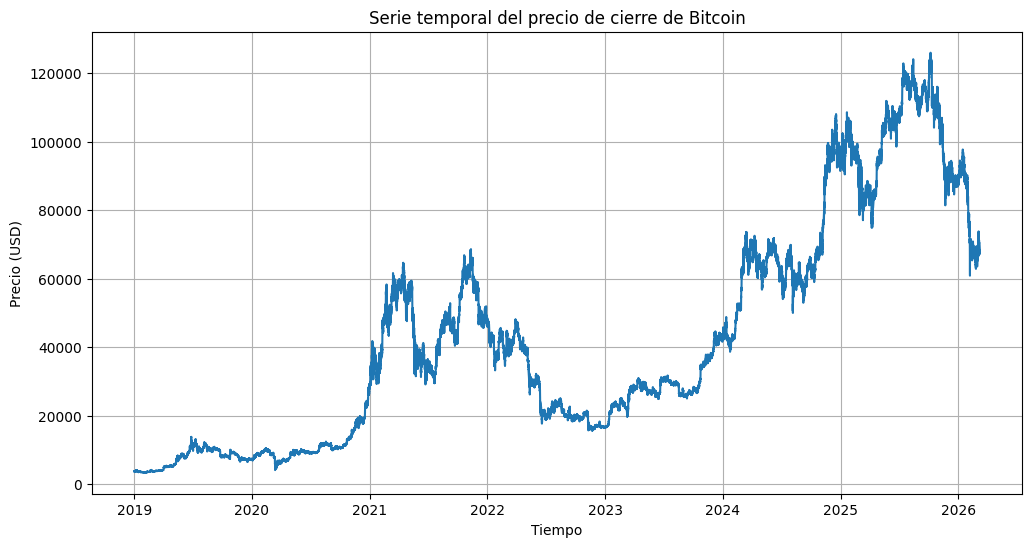

In [12]:

df = df.sort_index()

plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'])

plt.title("Serie temporal del precio de cierre de Bitcoin")
plt.xlabel("Tiempo")
plt.ylabel("Precio (USD)")
plt.grid(True)

plt.show()

Este gráfico presenta la evolución general del precio de cierre del Bitcoin frente al dolar desde el año 2019. Se puede ver que hubo un aumento considerable de su precio desde el año 2010, hasta llegar a su máximo histórico a finales del año 2025. Posteriormente se ha visto una correción de su precio, reflejando la volatilidad característica del mercado de criptomonedas.

#### Gráfica desagregada
#### Precios

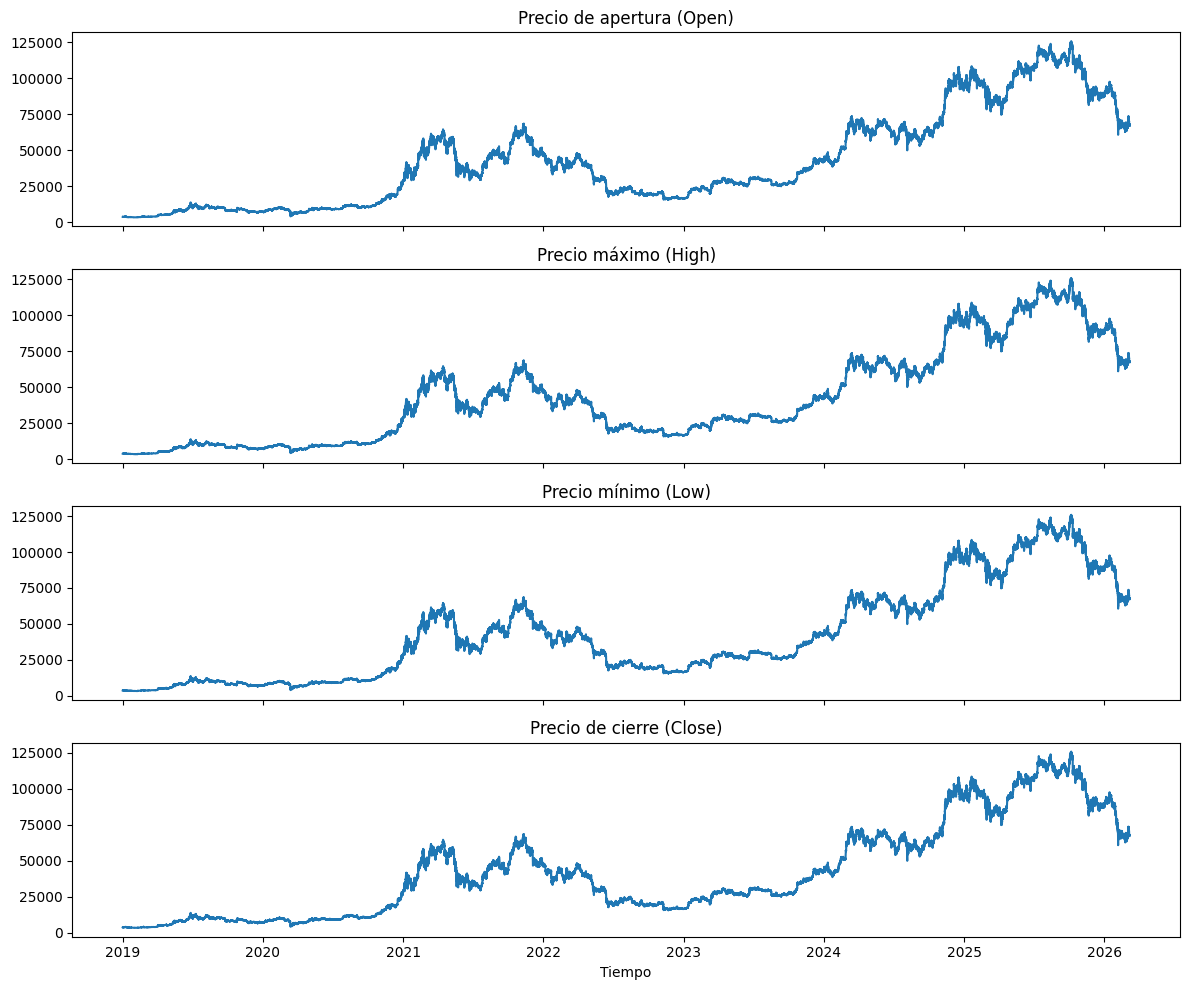

In [13]:
fig, axes = plt.subplots(4,1, figsize=(12,10), sharex=True)

axes[0].plot(df.index, df['Open'])
axes[0].set_title("Precio de apertura (Open)")

axes[1].plot(df.index  , df['High'])
axes[1].set_title("Precio máximo (High)")

axes[2].plot(df.index, df['Low'])
axes[2].set_title("Precio mínimo (Low)")

axes[3].plot(df.index, df['Close'])
axes[3].set_title("Precio de cierre (Close)")

plt.xlabel("Tiempo")
plt.tight_layout()
plt.show()

Las series correspondientes al precio de apertura, máximo, mínimo y cierre presentan comportamientos extremadamente similares al tratarse del mismo activo en un intervalo temporal muy corto. Se ven las mismas tendencias y eventualidades descritas previamente.

#### Volumen

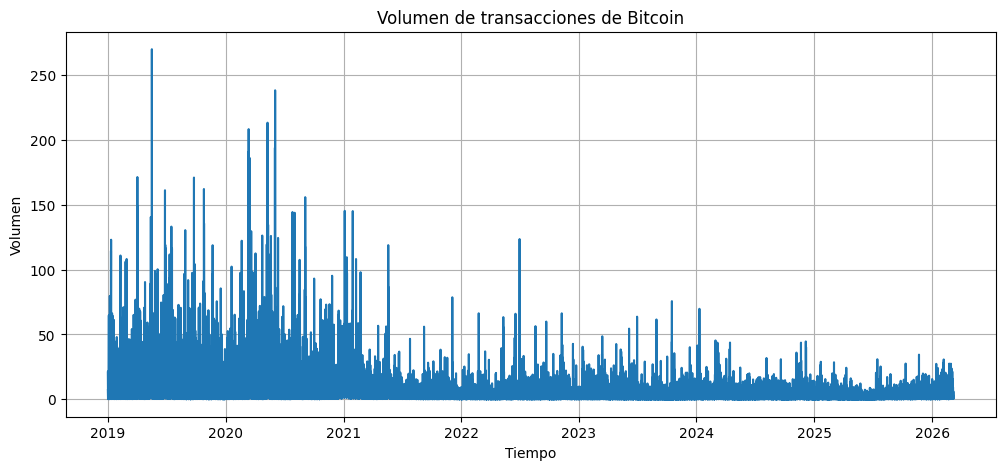

In [14]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Volume'])

plt.title("Volumen de transacciones de Bitcoin")
plt.xlabel("Tiempo")
plt.ylabel("Volumen")
plt.grid(True)

plt.show()

Por otro lado, el volumen presenta un comportamiento distinto a las demás variables con picos de gran volumen entre 2019 y 2021, lo cual podría hacer referencia a altos picos de actividad en ese periodo de tiempo. Esto se ve seguido a una disminución en los años 2022 y 2023, mientras que a partir de 2025, el volumen es mucho más bajo y estable.

### Análisis de componentes (Descomposición clásica)
El análisis de componentes de series temporales se define como la descomposición de la serie en elementos que permiten describir adecuadamente los patrones que la conforman. Generalmente una serie se descompone en: tendencia, estacionalidad y residuales. Para hacer la descomposición se utilizará la función *seasonal_decompose* que nos permitirá fraccionar la serie en sus componentes esenciales utilizando una descomposición clásica.

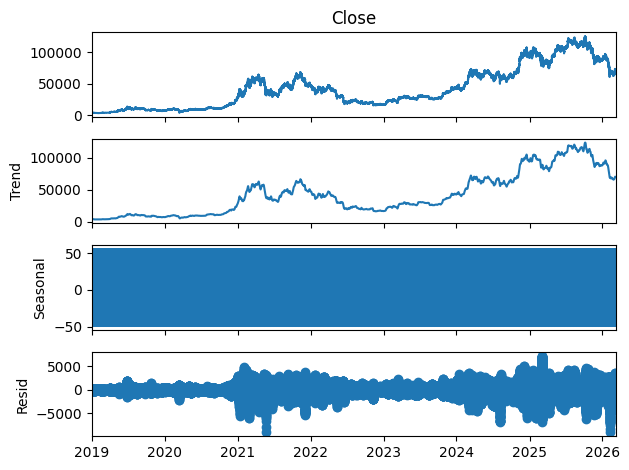

In [15]:
df = df.sort_index() 

from statsmodels.tsa.seasonal import seasonal_decompose

serie = df['Close'] 

decomposition = seasonal_decompose(serie, model='additive', period=365)

decomposition.plot()
plt.tight_layout()
plt.show()

#### Tendencia
La tendencia permite observar la evolución general del precio del Bitcoin, en esta ocasión, se utilizó el valor final en cada intervalo de tiempo. La función elimina las fluctuaciones de corto plazo presentes en la serie original y muestra el comportamiento estructural del mercado. Como se ve en el gráfico, la tendencia muestra un crecimiento notable en varios periodos, seguidos de épocas de correción dada la naturaleza correctiva de de los mercados financieros.


#### Estacionalidad
Describe qué tan seguido se presentan los patrones estacionales en una serie temporal. En activos financieros es normal que dependiendo su volatilidad no se presenten patrones estacionales. El segundo gráfico es practicamente plano, lo cual indica que el Bitcoin no tiene patrones estacionales anuales o mensuales, esto permite concluir que la variación está dominada más por eventos de mercado que por ciclos periódicos predecibles.

#### Residuales
Los residuales están compuestos por lo que queda de la serie luego de quitar la tendencia y la estacionalidad. En otras palabras, representan el ruido del mercado. En el tercer gráfico se puede ver que se tienen fluctuaciones significativas alrededor de 2021 a 2025, probablemente marcados por algún evento inesperado. Se puede concluir que, los picos de precios no siguen un patrón regular y están marcados por una alta volatilidad.

### Análisis de componentes (STL)
La descomposición clásica es una herramienta bastante útil para poder conocer como se compone una serie de tiempo, sin embargo, posee algunas limitaciones como un manejo limitado de outliers, una tendencia lineal y estacionalidad fija. La descomposición STL es una técnica más flexible que utiliza suavizado Loess para extraer la tendencia y estacionalidad de una manera más efectiva en series cambiantes no lineales como las financieras.

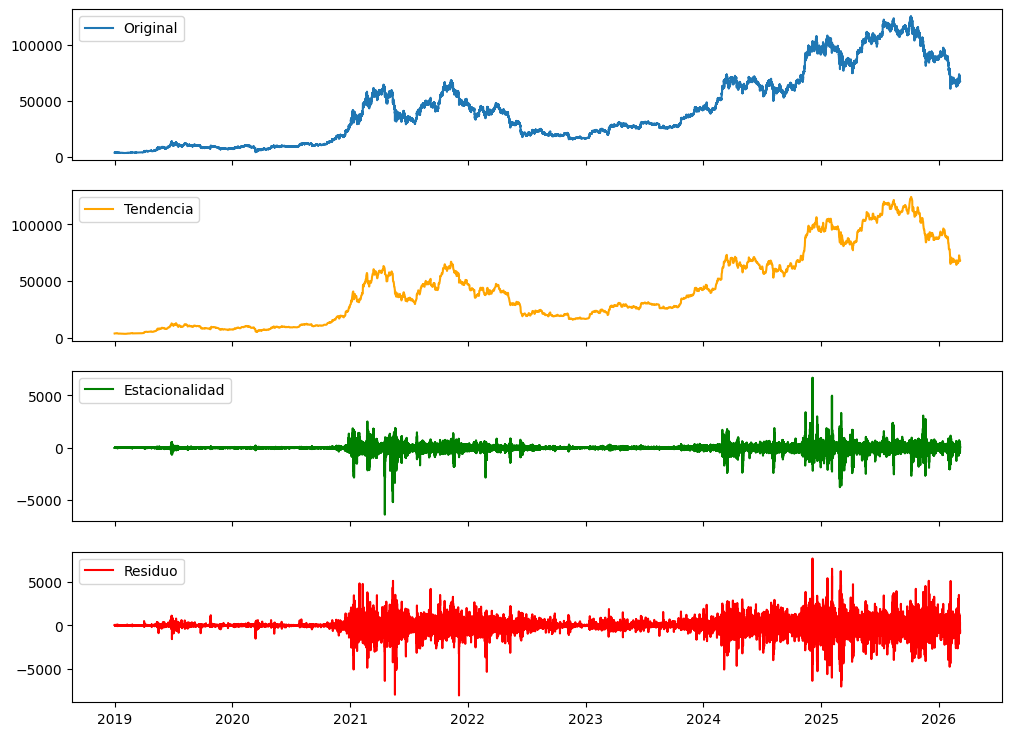

In [16]:
bitcoin_series = df['Close']  

stl = STL(bitcoin_series, period=48, robust=True)  
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(bitcoin_series, label='Original')
axes[0].legend(loc='upper left')
axes[1].plot(result.trend, label='Tendencia', color='orange')
axes[1].legend(loc='upper left')
axes[2].plot(result.seasonal, label='Estacionalidad', color='green')
axes[2].legend(loc='upper left')
axes[3].plot(result.resid, label='Residuo', color='red')
axes[3].legend(loc='upper left')
plt.show()

En esta ocasión, se configuró el STL para que capture ciclos cada 12 horas y busque patrones que se repitan en ese espacio de tiempo. En el resultado se presenta mucha similitud con respecto a la descomposición clásica en la distribución original y la tendencia, como los mismos picos alcistas en 2021 y 2025, seguidos de sus respectivos periodos de corrección. Por otro lado, para la estacionalidad se confirma que no es constante si no que escala con el precio, mientras que los residuos muestran eventos extremos en 2021 - 2022 y 2024 - 2025 coincidentes con los picos pronunciados en precio.

Dado que la amplitud de la estacionalidad y los residuos crecen proporcionalmente con respecto al precio, la varianza de la serie no es constante. Por lo que se procederá a realizar una transformación logaritmica para poder estabilizarla y hacer la descomposición más interpretable.

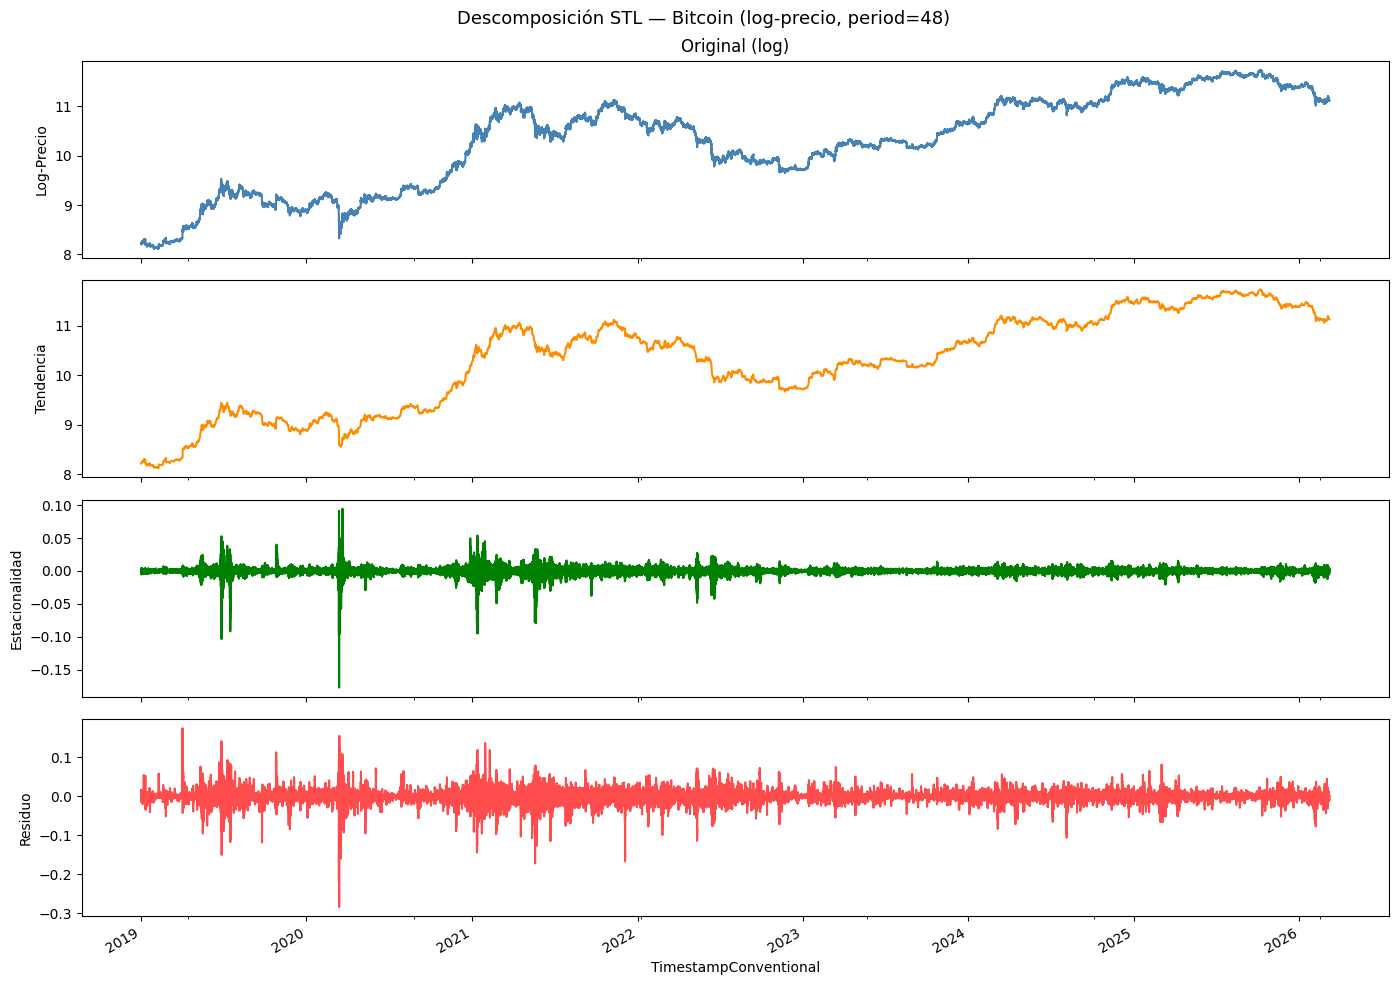

In [17]:

serie_log = np.log(df['Close'])

stl_log = STL(serie_log, period=48, robust=True)
result_log = stl_log.fit()

# Visualización
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

serie_log.plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('Log-Precio')
axes[0].set_title('Original (log)')

pd.Series(result_log.trend, index=serie_log.index).plot(ax=axes[1], color='darkorange')
axes[1].set_ylabel('Tendencia')

pd.Series(result_log.seasonal, index=serie_log.index).plot(ax=axes[2], color='green')
axes[2].set_ylabel('Estacionalidad')

pd.Series(result_log.resid, index=serie_log.index).plot(ax=axes[3], color='red', alpha=0.7)
axes[3].set_ylabel('Residuo')

plt.suptitle('Descomposición STL — Bitcoin (log-precio, period=48)', fontsize=13)
plt.tight_layout()
plt.show()

La serie original y la tendencia ahora muestan variaciones porcentuales en lugar de mostrar de absolutas, manteniendo los ciclos alcistas y bajistas visibles, sin embargo, las observaciones se muestran considerablemente mpas homogéneas. Lo mismo ocurre con la estacionalidad y residuo, ahora se distribuyen más homogéneamente alrededor de 0, con picos negativos pronunicados entre 2020 y 2021. Se concluye lo mismo, el Bitcoin no tiene una estacionalidad consistentemente fuerte.

### Detección de anomalías
Ahora, se estudiarán las anomalías o outliers presentes en la serie.

Número de días con outliers: 53


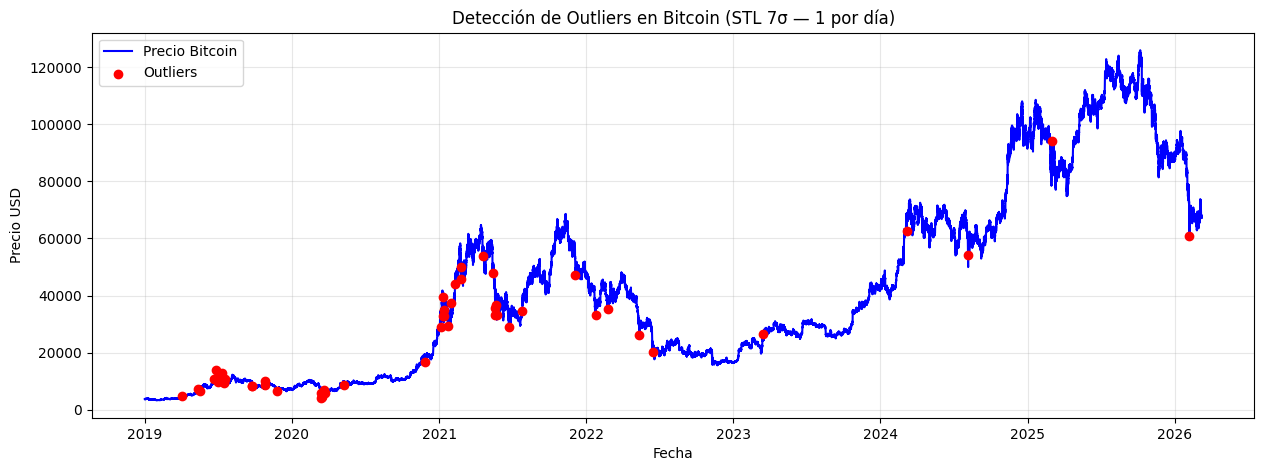

In [18]:
resid_log = pd.Series(result_log.resid, index=serie_log.index)

umbral = 7 * resid_log.std()
outliers = resid_log[abs(resid_log) > umbral]

outliers_diarios = outliers.groupby(outliers.index.date).apply(lambda x: x.abs().idxmax())
outliers_diarios = resid_log.loc[outliers_diarios.values]

print(f"Número de días con outliers: {len(outliers_diarios)}")

plt.figure(figsize=(15,5))
plt.plot(df.index, df['Close'], label='Precio Bitcoin', color='blue')
plt.scatter(outliers_diarios.index, df['Close'].loc[outliers_diarios.index],
            color='red', label='Outliers', zorder=5)
plt.title("Detección de Outliers en Bitcoin (STL 7σ — 1 por día)")
plt.xlabel("Fecha")
plt.ylabel("Precio USD")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
tabla_outliers = df['Close'].loc[outliers_diarios.index].reset_index()
tabla_outliers.columns = ['Fecha', 'Precio_USD']
tabla_outliers['Residuo'] = resid_log.loc[outliers_diarios.index].values
tabla_outliers['Tipo'] = tabla_outliers['Residuo'].apply(lambda x: '📈 Subida' if x > 0 else '📉 Caída')
tabla_outliers = tabla_outliers.sort_values('Fecha')
print(tabulate(tabla_outliers, headers='keys', tablefmt='pretty', showindex=False))

+---------------------+--------------------+----------------------+-----------+
|        Fecha        |     Precio_USD     |       Residuo        |   Tipo    |
+---------------------+--------------------+----------------------+-----------+
| 2019-04-02 09:15:00 | 4942.709333333333  | 0.17460716094019446  | 📈 Subida |
| 2019-05-12 03:15:00 |      7363.25       | 0.07612204953103152  | 📈 Subida |
| 2019-05-17 07:00:00 |      6709.574      | -0.09547746980701888 | 📉 Caída  |
| 2019-06-22 07:00:00 | 10813.155333333332 | 0.08710561407004569  | 📈 Subida |
| 2019-06-26 22:45:00 | 13793.564666666667 | 0.11414554837476665  | 📈 Subida |
| 2019-06-27 21:00:00 | 10709.368666666667 | -0.15024078882774283 | 📉 Caída  |
| 2019-06-28 01:45:00 | 10726.003999999999 | -0.0934216773212313  | 📉 Caída  |
| 2019-07-02 15:30:00 |      9741.858      | -0.08909776139518222 | 📉 Caída  |
| 2019-07-10 17:00:00 | 13053.740666666668 | 0.09277971632891813  | 📈 Subida |
| 2019-07-16 23:30:00 | 9613.808666666668  | -0.1

Para detectar los outliers, se utilizó la serie residual de la descomposición STL construida previamente. Los valores atípicos no se encuentran en la tendencia ni en la estacionalidad si no en lo que no se puede explicar de ambas, ahora, se utiliza el residuo de la transformación logaritmica porque los cambios relativos son comparables y la desviación ya no va a depender del nivel absoluto del precio. Finalmente, se utilizó un umbral alto y se agruparon los datos para reducir la gran cantidad de outliers encontrados en un día y hacer más preciso el resultado.

En total, se detectaron 53 eventos extremos entre 2019 y 2026. En el periodo de mitad de año de 2019 se concentraron muchas alzas y bajasndo a una subida de hasta casi 13000 USD, con su posterior corrección. En marzo 2020, hubo un crash provocado por el inicio de la cuarente provocada por la expansión del COVID-19, la cual está en linea con el colapso de todos los mercados financieros dada la coyuntura economica potenciada por la incertidumbre del momento. Durante 2021 hubo muchos movimientos extremos de tendencia alcista y bajistas marcados por la entrada de grandes inversores como Tesla y MicroStrategy, la prohibición de transacciónes con crypto en China, y la correción luego de su primer máximo histórico de 69.000 USD. En 2022, luego de otro pico histórico, se profundizó la tendencia bajista que se extendió hasta 2024. Hasta 2025 que solo fue testigo de un momento alcista hasta 2026 que se presentó otro evento extremo que marcó el inicio de una fase de corrección.

## Estacionalidad y periodicidad
### Análisis de patrones recurrentes
En esta sección se explorará como se repite el comportamiento de la serie en el tiempo. Para eso se utilzarán dos indicadores: 
- ACF: mide como se relaciona la serie con versiones pasadas de si misma.
- PACF: mide como se correlaciona una versión pasada de la serie ignorando la influecia de otra versión intermedia.


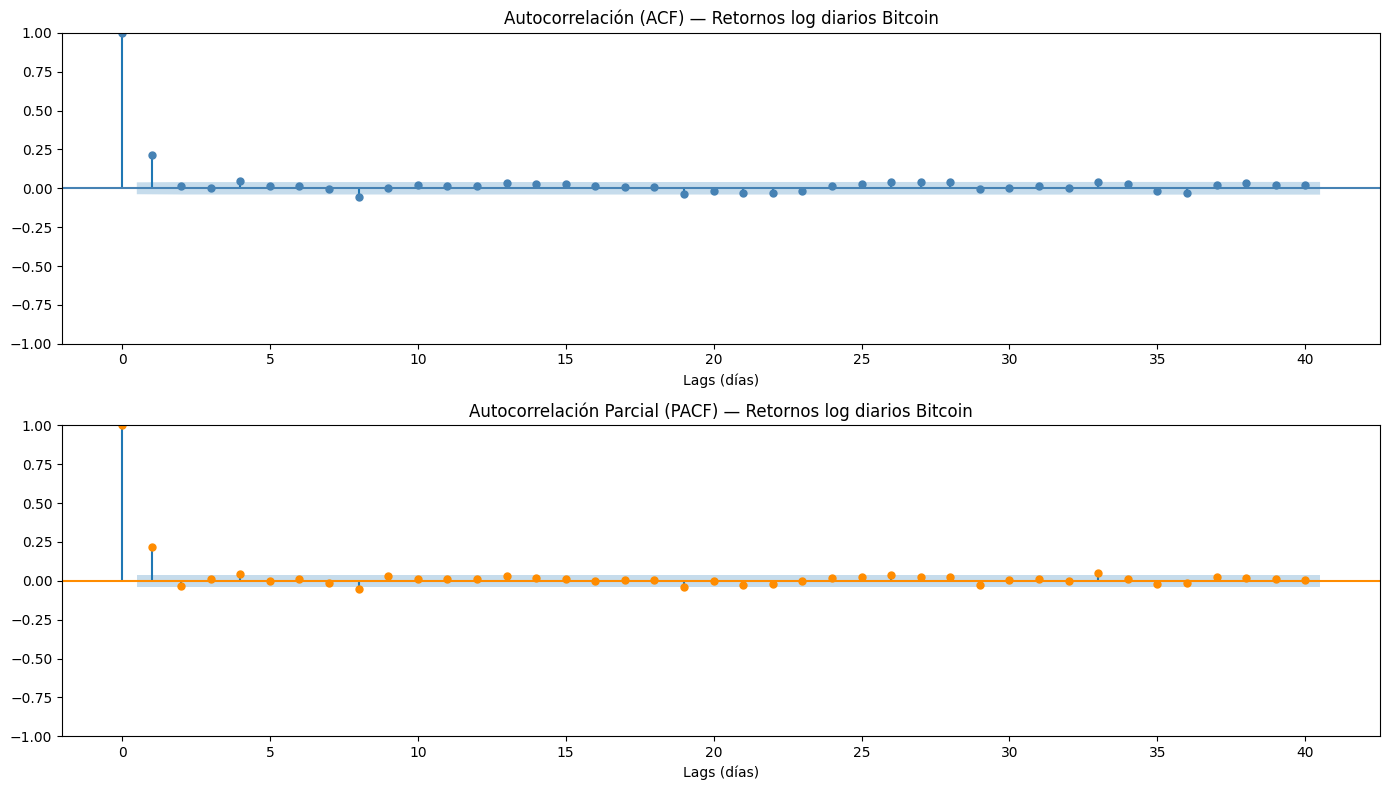

In [34]:

serie_diaria = df['Close'].resample('1D').mean().dropna()
retornos_diarios = np.log(serie_diaria / serie_diaria.shift(1)).dropna()

# ACF y PACF
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(retornos_diarios, lags=40, ax=axes[0], color='steelblue')
axes[0].set_title('Autocorrelación (ACF) — Retornos log diarios Bitcoin')
axes[0].set_xlabel('Lags (días)')

plot_pacf(retornos_diarios, lags=40, ax=axes[1], color='darkorange')
axes[1].set_title('Autocorrelación Parcial (PACF) — Retornos log diarios Bitcoin')
axes[1].set_xlabel('Lags (días)')

plt.tight_layout()
plt.show()

Lo anterior nos eprmite interpretar que los retornos de Bitcoin dependen muy poco del pasado, solo el día inmediatamente anterior tiene una influencia leve. No existentes patrones largos que se puedan aprovechar.

/var/folders/x3/pv5pxgpn24d3dg_tsmkjptgc0000gn/T/ipykernel_71994/4209595986.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='DiaSemana', y='Close', order=orden, palette='Blues')


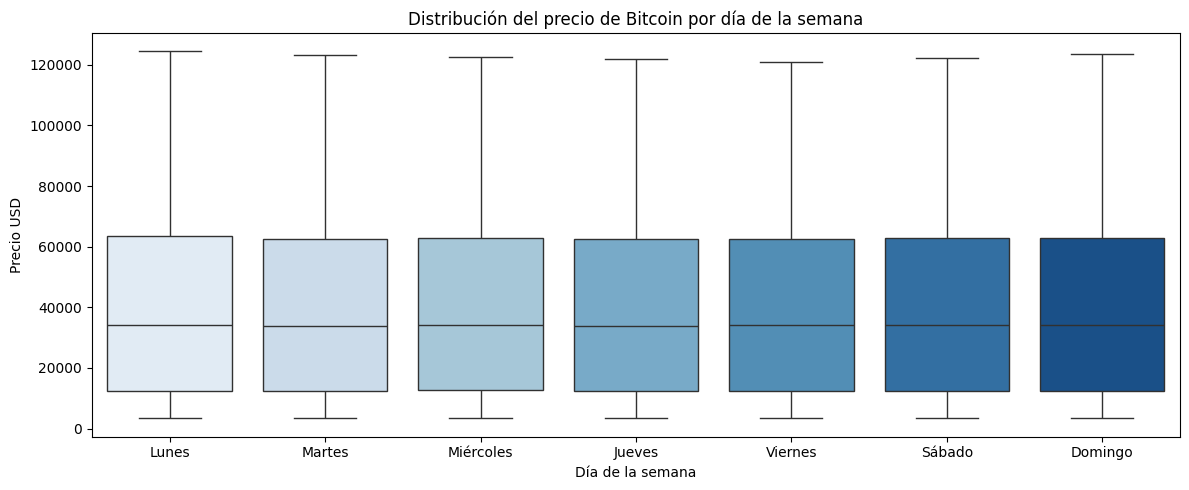

In [35]:

dias = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes', 5:'Sábado', 6:'Domingo'}

df_box = df['Close'].resample('1D').mean().dropna().reset_index()
df_box.columns = ['Fecha', 'Close']
df_box['DiaSemana'] = df_box['Fecha'].dt.dayofweek.map(dias)

orden = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_box, x='DiaSemana', y='Close', order=orden, palette='Blues')
plt.title('Distribución del precio de Bitcoin por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Precio USD')
plt.tight_layout()
plt.show()

El Bitcoin es un mercado que opera las 24 horas todos los días. Del gráfico anterior se puede ver que el día de la semana no afecta el precio, por lo que no será un feature determinante en el modelos de predicción de precios. Las medianas y rangos intercuartilicos son muy similares todos los días, no hay bigotes que resalten un día sobre otro,

### Transformación del dominio del tiempo
En esta sección se observará la serie en distintas frecuencias para intentar identificar patrones distintos a los ya observados en la frecuencia de 15 min. 

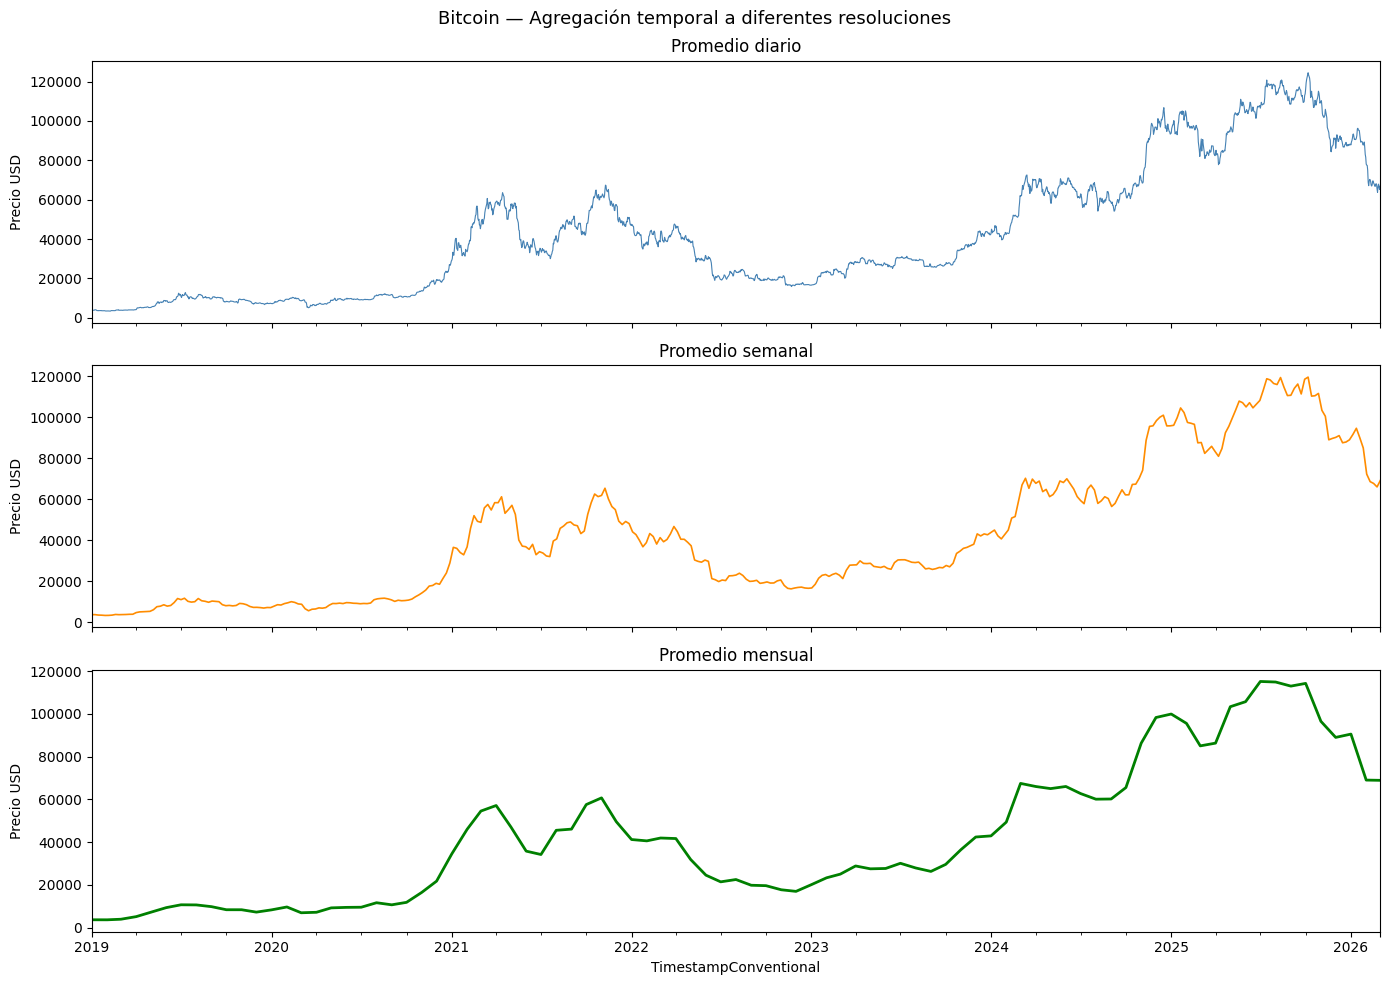

In [36]:
resample_diario   = df['Close'].resample('1D').mean().dropna()
resample_semanal  = df['Close'].resample('1W').mean().dropna()
resample_mensual  = df['Close'].resample('1ME').mean().dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

resample_diario.plot(ax=axes[0], color='steelblue', linewidth=0.8)
axes[0].set_title('Promedio diario')
axes[0].set_ylabel('Precio USD')

resample_semanal.plot(ax=axes[1], color='darkorange', linewidth=1.2)
axes[1].set_title('Promedio semanal')
axes[1].set_ylabel('Precio USD')

resample_mensual.plot(ax=axes[2], color='green', linewidth=2)
axes[2].set_title('Promedio mensual')
axes[2].set_ylabel('Precio USD')

fig.suptitle('Bitcoin — Agregación temporal a diferentes resoluciones', fontsize=13)
plt.tight_layout()
plt.show()

In [40]:
resumen_anual = df['Close'].resample('1YE').agg(['mean','median','std','min','max'])
resumen_anual.index = resumen_anual.index.year
resumen_anual.columns = ['Promedio', 'Mediana', 'Desv. Est.', 'Mínimo', 'Máximo']
resumen_anual['Promedio'] = resumen_anual['Promedio'].map('${:,.0f}'.format)
resumen_anual['Mediana']  = resumen_anual['Mediana'].map('${:,.0f}'.format)
resumen_anual['Mínimo']   = resumen_anual['Mínimo'].map('${:,.0f}'.format)
resumen_anual['Máximo']   = resumen_anual['Máximo'].map('${:,.0f}'.format)
resumen_anual['Desv. Est.'] = resumen_anual['Desv. Est.'].map('${:,.0f}'.format)

print(tabulate(resumen_anual, headers='keys', tablefmt='fancy_grid'))

╒═════════════════════════╤════════════╤═══════════╤══════════════╤══════════╤══════════╕
│   TimestampConventional │ Promedio   │ Mediana   │ Desv. Est.   │ Mínimo   │ Máximo   │
╞═════════════════════════╪════════════╪═══════════╪══════════════╪══════════╪══════════╡
│                    2019 │ $7,351     │ $7,824    │ $2,648       │ $3,351   │ $13,823  │
├─────────────────────────┼────────────┼───────────┼──────────────┼──────────┼──────────┤
│                    2020 │ $11,063    │ $9,696    │ $4,227       │ $4,123   │ $29,231  │
├─────────────────────────┼────────────┼───────────┼──────────────┼──────────┼──────────┤
│                    2021 │ $47,376    │ $47,927   │ $9,827       │ $28,859  │ $68,599  │
├─────────────────────────┼────────────┼───────────┼──────────────┼──────────┼──────────┤
│                    2022 │ $28,244    │ $23,166   │ $10,206      │ $15,587  │ $48,121  │
├─────────────────────────┼────────────┼───────────┼──────────────┼──────────┼──────────┤
│         

Para la distribución díaria, la volatilidad es bastante notoria especialmente en los periodos 2021 y 2024-2025. El ruido se verá significativamente reducido en el promedio semanal, tambien se aprecia la asimetria de los ciclos de Bitcoin con subidas graduales y caidas abruptas. En el promedio mensual se distinguen 3 fases: 2019-2020, el cliclo alcista de 2021 y el segundo ciclo alcista de 2024-2025 que superó los 100.000, esta descripción refuerza la afirmación sobre la tendencia no estacionaria del Bitcoin.

## Análisis de tendencia
En esta sección se buscará identificar la dirección del precio del Bitcoin. Para eso, en el corto plazo se separará del ruido utilizando técnicas como medias móviles simples, suavización exponencial simple y doble y regresión polinómica. 

### Medias móviles
Es uno de los métodos más fáciles de implementar cuando se busca eliminar el ruido de alta frecuencia de una serie se trata. Para construir el suavizado, calcula el promedio de los últimos n valores de la serie.

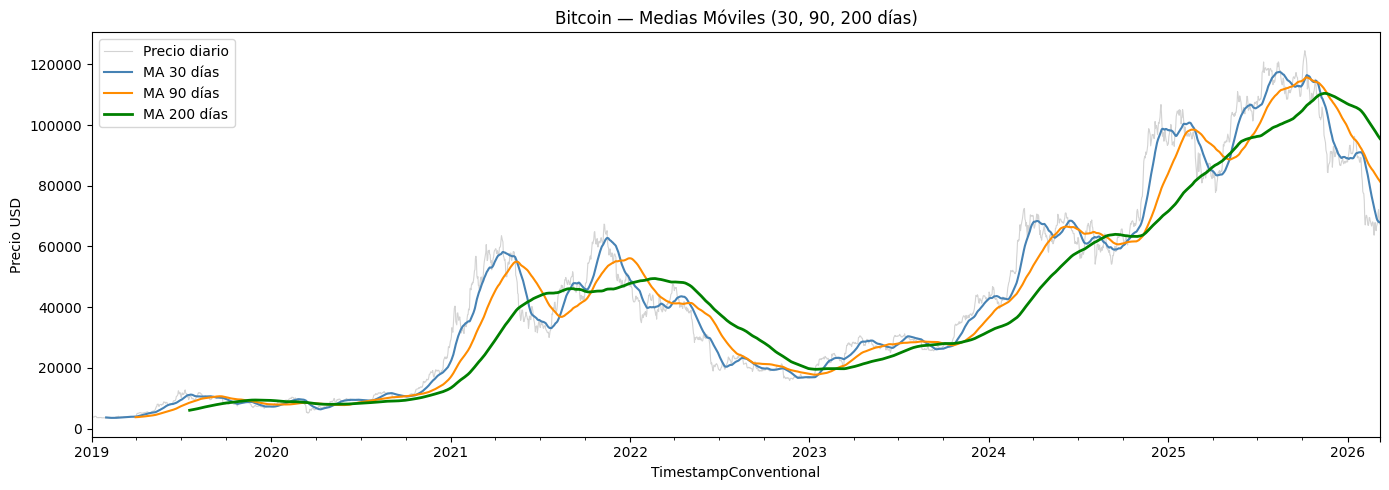

In [41]:
fig, ax = plt.subplots(figsize=(14, 5))

serie_diaria.plot(ax=ax, color='lightgray', linewidth=0.8, label='Precio diario')
serie_diaria.rolling(window=30).mean().plot(ax=ax, color='steelblue', linewidth=1.5, label='MA 30 días')
serie_diaria.rolling(window=90).mean().plot(ax=ax, color='darkorange', linewidth=1.5, label='MA 90 días')
serie_diaria.rolling(window=200).mean().plot(ax=ax, color='green', linewidth=2, label='MA 200 días')

ax.set_title('Bitcoin — Medias Móviles (30, 90, 200 días)')
ax.set_ylabel('Precio USD')
ax.legend()
plt.tight_layout()
plt.show()

Las 3 medias móviles permiten ver la estructura de la tendencia del Bitcoin. La MA de 30 dias captura con más detalle los movimientos a largo plazo, sin embargo, tambien presenta mayor ruido. Por otro lado, la MA de 90 días sigue los ciclos alcistas y bajistas con buen detalle y mayor claridad, al no tener tanto ruido. Finalmente, la MA de 200 días es la más suave y sirve para mostrar la tendencia en el largo plazo, destacando los movimientos alcistas de 2021-2022, mostrando la caida a mediados de 2023, y la subida de 2025 que llevó al Bitcoin a superar su máximo histórico.

### Suavizado Exponencial Simple
Busca suavizar la serie asignando más peso a los datos más recientes. Se puede controlar el peso que se les asignará a los úlitmos valores, adaptandose mejor que las medias móviles, sin embargo, no captura bien series con una fuerte tendencia.

Lambda óptimo: 0.96 | MAE: 1125.44


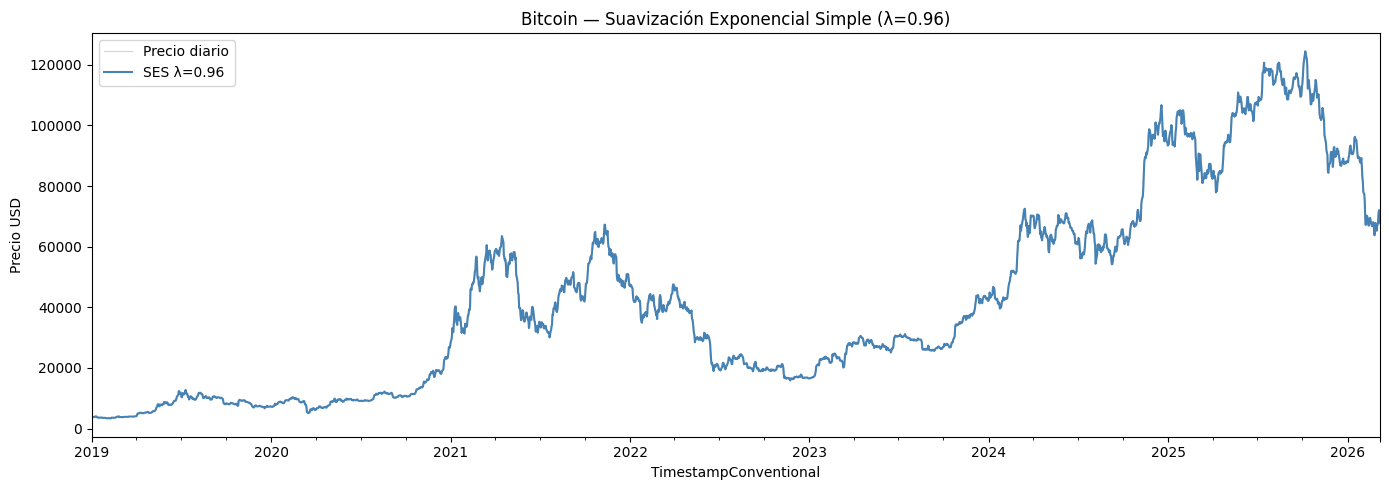

In [43]:

lambdas = np.arange(0.01, 1.0, 0.05)
mejor_lambda, mejor_mae = None, float("inf")

for lam in lambdas:
    modelo = SimpleExpSmoothing(serie_diaria.values).fit(smoothing_level=lam, optimized=False)
    mae = mean_absolute_error(serie_diaria.values[1:], modelo.fittedvalues[:-1])
    if mae < mejor_mae:
        mejor_lambda, mejor_mae = lam, mae

print(f"Lambda óptimo: {mejor_lambda:.2f} | MAE: {mejor_mae:.2f}")

ses_model = SimpleExpSmoothing(serie_diaria.values).fit(smoothing_level=mejor_lambda, optimized=False)
ses_fitted = pd.Series(ses_model.fittedvalues, index=serie_diaria.index)

fig, ax = plt.subplots(figsize=(14, 5))
serie_diaria.plot(ax=ax, color='lightgray', linewidth=0.8, label='Precio diario')
ses_fitted.plot(ax=ax, color='steelblue', linewidth=1.5, label=f'SES λ={mejor_lambda:.2f}')
ax.set_title(f'Bitcoin — Suavización Exponencial Simple (λ={mejor_lambda:.2f})')
ax.set_ylabel('Precio USD')
ax.legend()
plt.tight_layout()
plt.show()

Con un lambda de 0.96, el modelo asignó casi todo el peso a las observaciones más recientes, esto tiene sentido dada la naturaleza volátil del Bitcoin. Con este lambda, la suavización exponencial solo sigue el precio diario sin suavizar significativamente la tendencia.

### Suavizado Exponencial Doble
Extiende la suavización simple agregando un componente de tendencia, por lo que permite capturar el nivel actual y la dirección de la serie. Aún así, es sensible a los cambios fuertes o complejas estacionalidades.

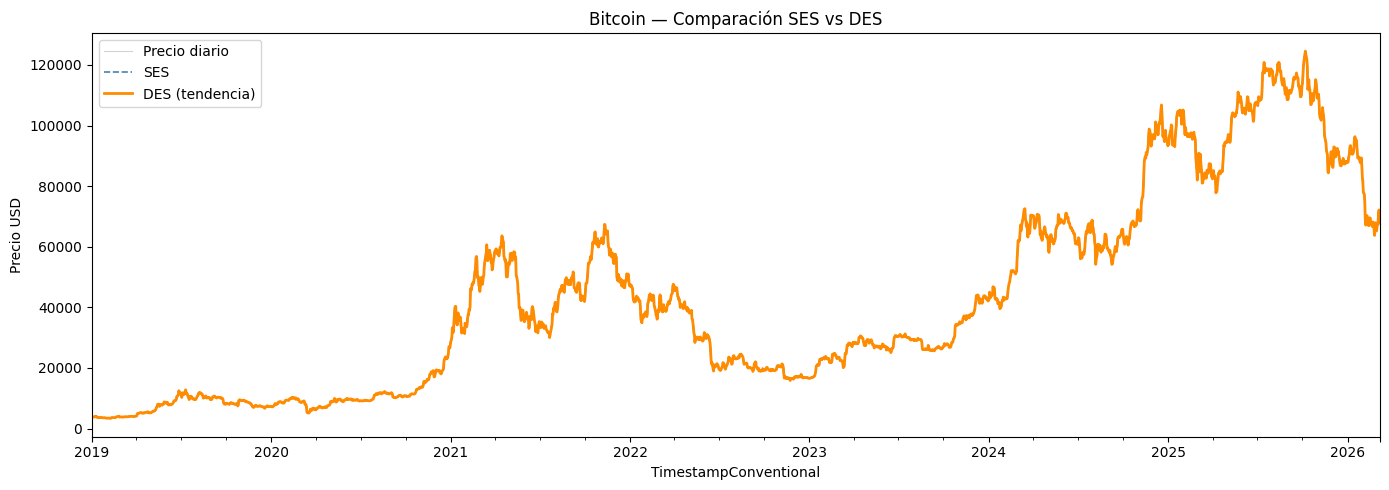

In [44]:
des_model = ExponentialSmoothing(serie_diaria, trend='add').fit()
des_fitted = pd.Series(des_model.fittedvalues, index=serie_diaria.index)

fig, ax = plt.subplots(figsize=(14, 5))
serie_diaria.plot(ax=ax, color='lightgray', linewidth=0.8, label='Precio diario')
ses_fitted.plot(ax=ax, color='steelblue', linewidth=1.2, label='SES', linestyle='--')
des_fitted.plot(ax=ax, color='darkorange', linewidth=2, label='DES (tendencia)')
ax.set_title('Bitcoin — Comparación SES vs DES')
ax.set_ylabel('Precio USD')
ax.legend()
plt.tight_layout()
plt.show()

Este gráfico muestra que el suavizado exponencial simple es visualmente indistinguible del suavizado exponencial doble. Dado el lambda tan alto encontrado, ambos metodos reaccionaron de forma muy similar a los cambios de precio, por tanto, el componente de tendencia lineal que aporta este método de suavizado no impacta sustancialmente al ajuste.

### Regresión Polinómica
Busca ajustar una función polinomica a la serie capturando curvas y cambios en la pendiente que una función lineal no podría. Puede generar un sobreajuste a la serie si el grado del polinomio es muy alto.

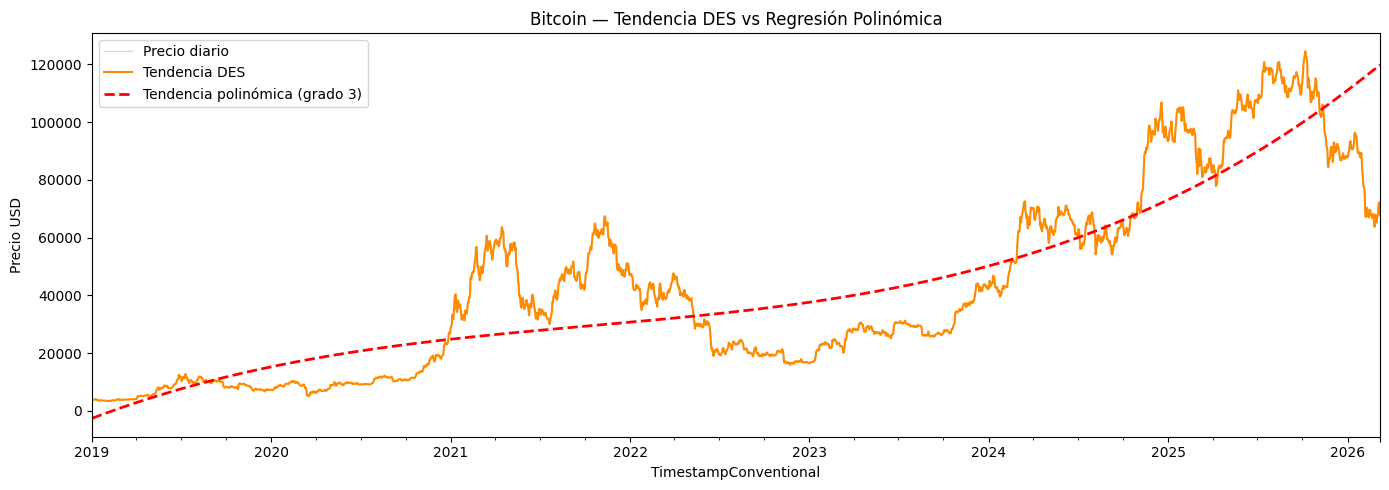

In [ ]:
from numpy.polynomial import polynomial as P

x = np.arange(len(serie_diaria))
y = serie_diaria.values

# Regresión polinómica grado 3
coefs = np.polyfit(x, y, deg=3)
poly_trend = np.polyval(coefs, x)

fig, ax = plt.subplots(figsize=(14, 5))
serie_diaria.plot(ax=ax, color='lightgray', linewidth=0.8, label='Precio diario')
des_fitted.plot(ax=ax, color='darkorange', linewidth=1.5, label='Tendencia DES')
ax.plot(serie_diaria.index, poly_trend, color='red', linewidth=2, linestyle='--', label='Tendencia polinómica (grado 3)')
ax.set_title('Bitcoin — Tendencia DES vs Regresión Polinómica')
ax.set_ylabel('Precio USD')
ax.legend()
plt.tight_layout()
plt.show()

Con una única curva continua, la regresión polinómica de grado 3 busca capturar la tendencia general de toda la serie del Bitcoin entre los años 2019 - 2026. Se nota que subestima bastante el precio en la primera subida sustancial del año 2021 y lo sobreestima al final de la serie en 2026, donde en lugar de mostrar la tendencia bajista, sube.

De forma consistente con lo encontrado al aplicar ACF y PACF, se concluye que el Bitcoin tiene una memoria corta dado que el predictor más influyente sobre su precio en el día de hoy, será el precio que haya alcanzado el día de ayer. La MA de 200 días es quizá, la herramienta más util para identificar el comportamiento general de la serie a lo largo del tiempo.

## Estabilidad de la serie
En esta sección se profundizará sobre la estacionariedad de la serie. Se verificará si la media y varianza son constantes a lo largo del tiempo y si la autocorrelación no cambia.

### Análisis de estacionariedad
#### Dickey-Fuller aumentado y Kwiatkowski-Phillips-Schmidt-Shin
Estos métodos buscan determinar si una serie es estacionaria o no. El método ADF sostiene como hipotesis nula que la serie no es estacionaria, mientras que el método KPSS sostiene la tesis contraria, la tesis si es estacionaria. Ambas pruebas se complementan y ofrecen una perspectiva robusta sobre la estacionariedad de la serie.

In [ ]:

adf_result = adfuller(serie_diaria, autolag='AIC')

print("PRUEBA DICKEY-FULLER AUMENTADO (ADF)")
print(f"  p-valor         : {adf_result[1]:.4f}")

if adf_result[1] > 0.05:
    print("NO estacionaria ")
else:
    print("Estacionaria")

print("PRUEBA KPSS")
kpss_result = kpss(serie_diaria, regression='c', nlags='auto')
print(f"  p-valor         : {kpss_result[1]:.4f}")
if kpss_result[1] < 0.05:
    print("NO estacionaria")
else:
    print("Estacionaria")



PRUEBA DICKEY-FULLER AUMENTADO (ADF)
  p-valor         : 0.6278
NO estacionaria (raíz unitaria)
PRUEBA KPSS
  p-valor         : 0.0100
NO estacionaria


/var/folders/x3/pv5pxgpn24d3dg_tsmkjptgc0000gn/T/ipykernel_71994/2264046656.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(serie_diaria, regression='c', nlags='auto')


#### Visualización de media y varianza
Para visualizar este gráfico, se dividirá la serie en periodos pequeños sobre los que se calcularán la media y variaza, si estos valores varían mucho, la serie no es estacionaria.

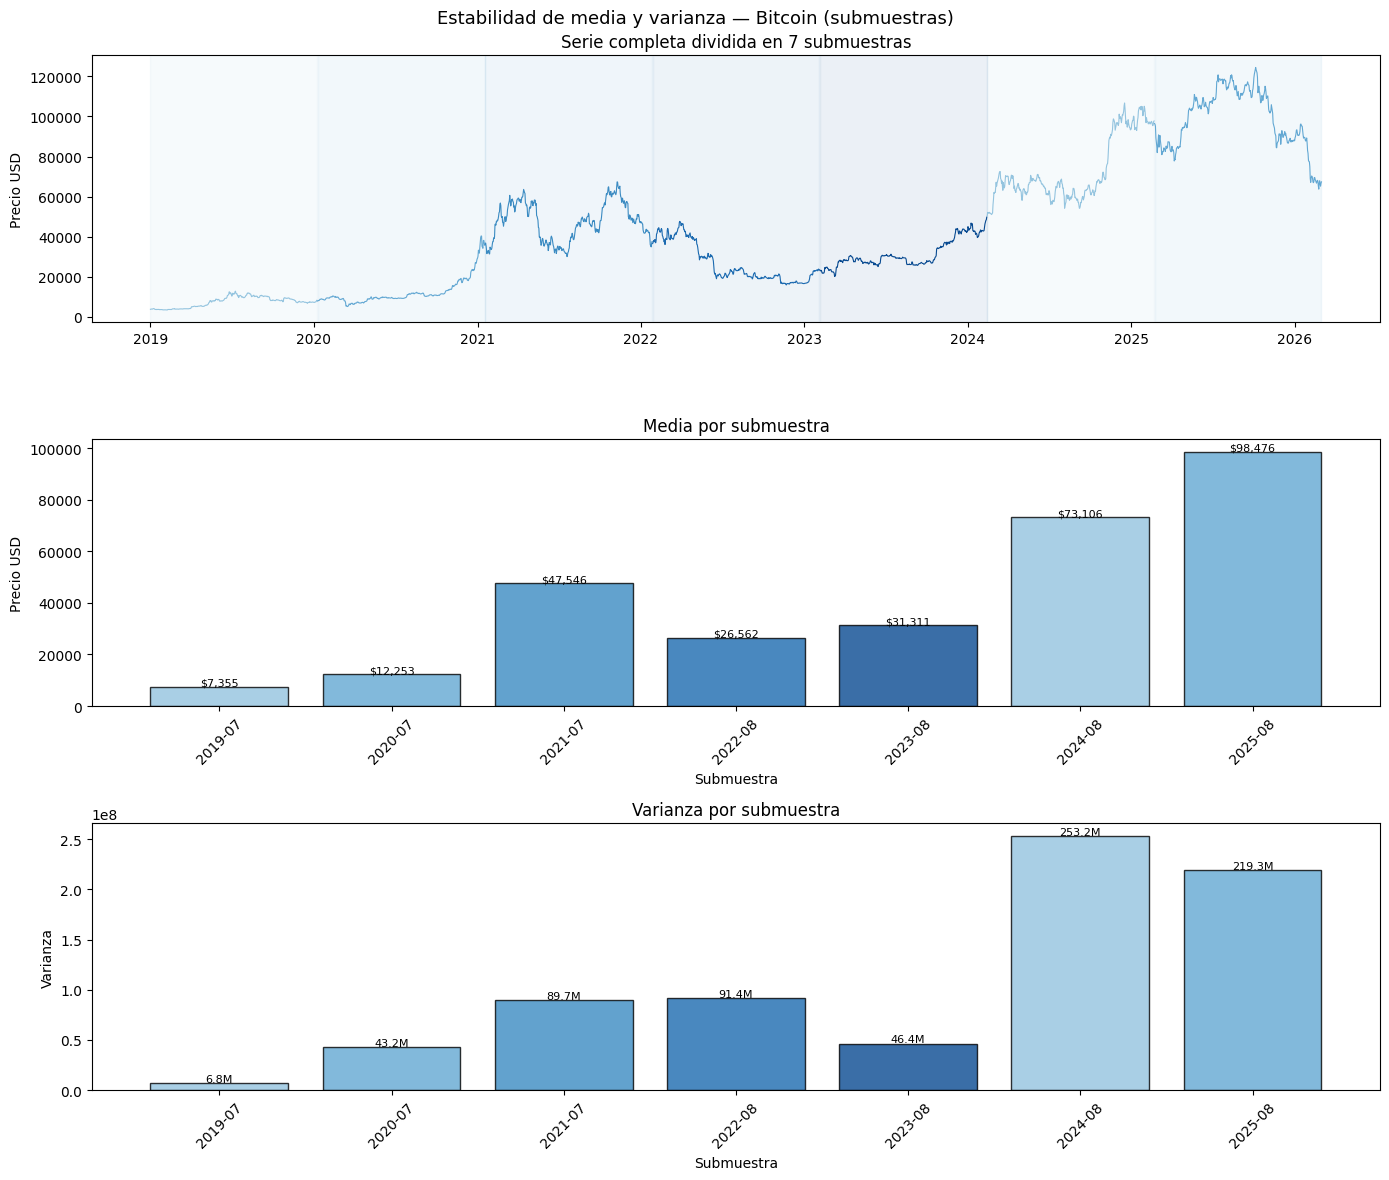

In [61]:
n_splits = 7
split_size = len(serie_diaria) // n_splits
submuestras = [serie_diaria.iloc[i*split_size:(i+1)*split_size] for i in range(n_splits)]

medias    = [s.mean() for s in submuestras]
varianzas = [s.var() for s in submuestras]
fechas    = [s.index[len(s)//2] for s in submuestras]  

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)


x = np.linspace(0, 10, 100)
N = 5  # número de tonos
cmap = plt.cm.Blues
colores = [cmap(0.4 + 0.5*i/(N-1)) for i in range(N)]

for i, s in enumerate(submuestras):
    axes[0].plot(s.index, s.values, color=colores[i % len(colores)], linewidth=0.8)
    axes[0].axvspan(s.index[0], s.index[-1], alpha=0.08, color=colores[i % len(colores)])
axes[0].set_title('Serie completa dividida en 7 submuestras')
axes[0].set_ylabel('Precio USD')

#Media
axes[1].bar(range(n_splits), medias, color=colores[:n_splits], edgecolor='black', alpha=0.8)
axes[1].set_title('Media por submuestra')
axes[1].set_ylabel('Precio USD')
axes[1].set_xlabel('Submuestra')
axes[1].set_xticks(range(n_splits))
axes[1].set_xticklabels([f.strftime('%Y-%m') for f in fechas], rotation=45)
for i, v in enumerate(medias):
    axes[1].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=8)

#Varianza
axes[2].bar(range(n_splits), varianzas, color=colores[:n_splits], edgecolor='black', alpha=0.8)
axes[2].set_title('Varianza por submuestra')
axes[2].set_ylabel('Varianza')
axes[2].set_xlabel('Submuestra')
axes[2].set_xticks(range(n_splits))
axes[2].set_xticklabels([f.strftime('%Y-%m') for f in fechas], rotation=45)
for i, v in enumerate(varianzas):
    axes[2].text(i, v + 1e6, f'{v/1e6:.1f}M', ha='center', fontsize=8)

plt.suptitle('Estabilidad de media y varianza — Bitcoin (submuestras)', fontsize=13)
plt.tight_layout()
plt.show()

El gráfico anterior y las pruebas de Dickey-Fuller aumentado y Kwiatkowski-Phillips-Schmidt-Shin llegan a la misma conclusión: la serie temporal del Bitcoin no es estacionaria. Se puede ver que la media y varianza cambian drásticamente a lo largo del tiempo. Para la media, en el año 2019 se tiene un valor de 7,355 USD que crecerá hasta los 98000 USD en el año 2025, comporamiento que nos permite concluir que la media no es constante. Por otro lado, la varianza tambien fue muy cambiante, tomando un valor de 6.8M hasta llegar a los 253.2M, concluyendo que no sigue un patrón monotono, confirmando la heterocedasticidad identificada en la aplicación del STL.

### Transformaciones de datos.

Múltiples modelos asumen estacionariedad en la serie que se aplican. Hasta ahora, las pruebas realizadas sobre la serie del Bitcoin han llevado a la conclusión de que no es estacionaria, por lo cual, se hace necesario aplicar variadas transformaciones que conviertan a la serie en estacionaria. Para esto, se aplicarán las pruebas ADF y KPSS para determinar si la transformación cumple con el objetivo o no.

In [68]:
def test_estacionariedad(serie, nombre):
    adf = adfuller(serie.dropna(), autolag='AIC')
    kpss_r = kpss(serie.dropna(), regression='c', nlags='auto')
    if adf[1] > 0.05:
        print("ADF: NO estacionaria ")
    else:
        print("Estacionaria")
        
    if kpss_r[1] < 0.05:
        print("KPSS: NO estacionaria")
    else:
        print("KPSS: Estacionaria")


#### Log
La prueba anterior concluyó que la varianza crece con el precio, para solucionar eso, se aplicará una transformación logarítmica que comprimirá los valores grandes y estabilizará la varianza.

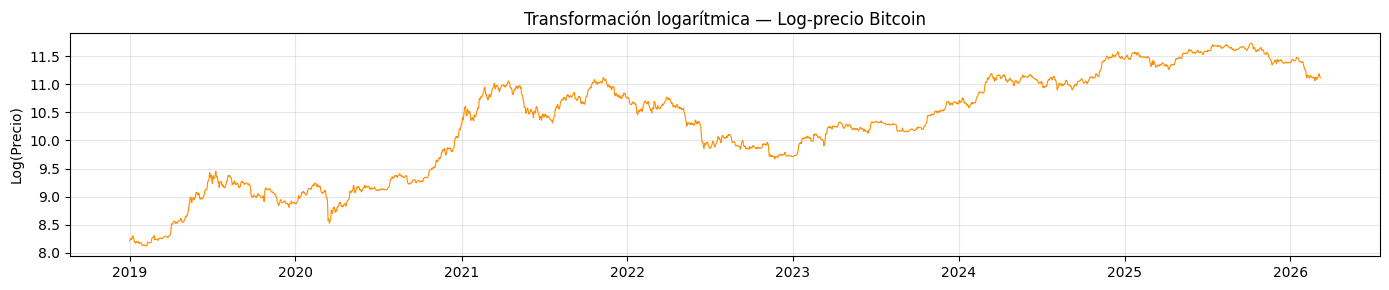

ADF: NO estacionaria 
KPSS: NO estacionaria


In [69]:
serie_log = np.log(serie_diaria)

plt.figure(figsize=(14, 3))
plt.plot(serie_log, color='darkorange', linewidth=0.8)
plt.title('Transformación logarítmica — Log-precio Bitcoin')
plt.ylabel('Log(Precio)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

test_estacionariedad(serie_log, "Log-precio")

La transformación logaritmica no es estacionaria, sigue mostrando la misma tendencia creciente de la serie original, únicamente funciona para estabilizar la varianza, pero no elimina la tendencia.

#### Primera diferencia
La prueba anterior concluyó que la media es cambiante, esta transformación permitirá conocer cómo cambio el precio de cierre en el día a día.

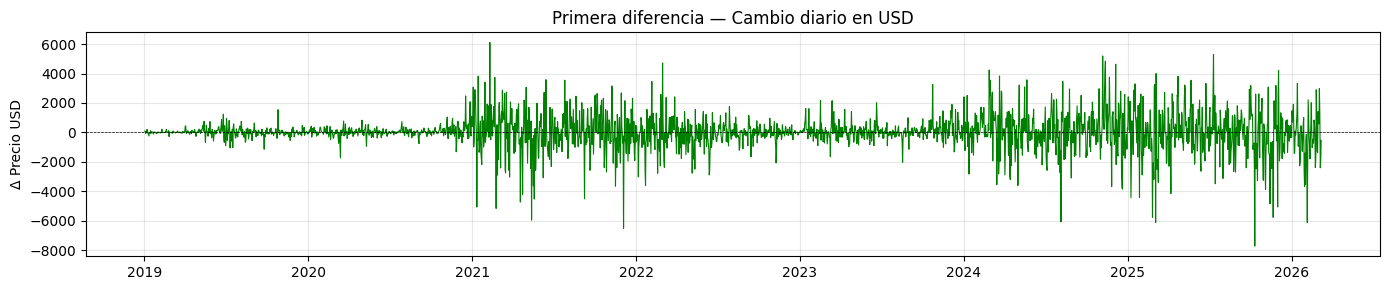

Estacionaria
KPSS: Estacionaria


In [70]:
serie_diff = serie_diaria.diff().dropna()

plt.figure(figsize=(14, 3))
plt.plot(serie_diff, color='green', linewidth=0.8)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('Primera diferencia — Cambio diario en USD')
plt.ylabel('Δ Precio USD')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

test_estacionariedad(serie_diff, "Primera diferencia")

La transformación de primera diferencia es estacionaria, pues en lugar de usar el precio, trabaja con el cambio absoluto diario en USD. Se ve como la serie oscila alrededor de 0 con una media constante, aunque si se percibe oscilaciones muy grandes en 2021 y 2025, lo cual muestra que la varianza no es constante.

#### Diferencia logarítmica
Ataca el problema de media cambiante y varianza inestable calculando el porcentaje de cambio diario y los retornos.

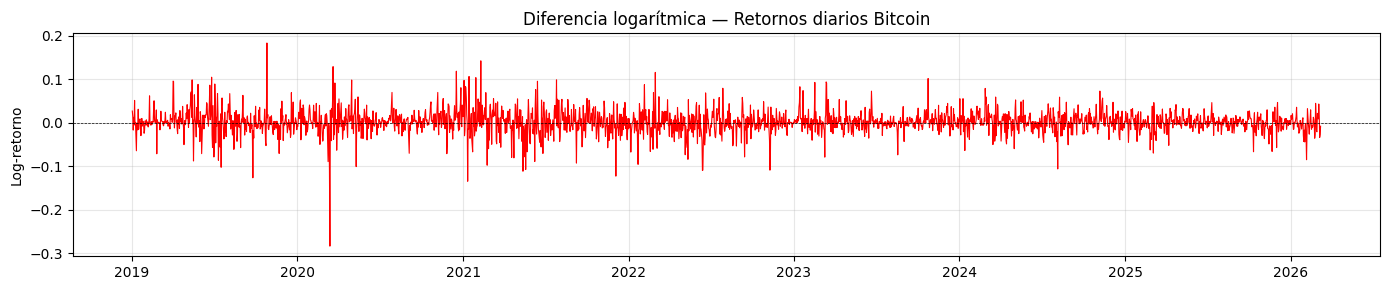

Estacionaria
KPSS: Estacionaria


In [71]:
serie_log_diff = np.log(serie_diaria).diff().dropna()

plt.figure(figsize=(14, 3))
plt.plot(serie_log_diff, color='red', linewidth=0.8)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('Diferencia logarítmica — Retornos diarios Bitcoin')
plt.ylabel('Log-retorno')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

test_estacionariedad(serie_log_diff, "Diferencia log (retornos)")

La transformación de la diferencia logaritmica es estacionaria, representa el retorno porcentual diario y oscila alrededor de 0 con varianza visualmente más homogénea que la transformación anterior.

#### Estandarización Z score
Busca corregir escala y media centralizando en 0 y normalizando los datos sin eliminar la tendencia.

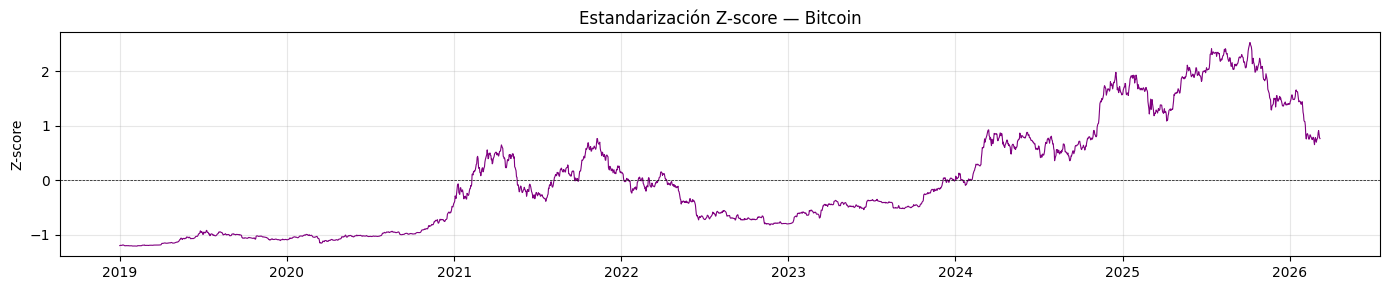

ADF: NO estacionaria 
KPSS: NO estacionaria


In [72]:
serie_zscore = (serie_diaria - serie_diaria.mean()) / serie_diaria.std()

plt.figure(figsize=(14, 3))
plt.plot(serie_zscore, color='purple', linewidth=0.8)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('Estandarización Z-score — Bitcoin')
plt.ylabel('Z-score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

test_estacionariedad(serie_zscore, "Estandarización Z-score")

La estandarización Z score no es estacionaria, apesar de centrar la serie en 0 no elimina la tendencia, por lo que solo se ve una reescala en los valores.

De las 4 transformaciones evaluadas, la primera diferencia y la diferencia logarítmica logran hacer que la serie sea estacionaria. Aún así, la diferencia logaritmica tiene una varianza más heterogenea con respecto a la primera diferencia, por lo que se toma esa transformación como la definitiva.